## CASTER

In [10]:
from pathlib import Path
import pandas as pd
import numpy as np
from phlag.caster import CasterPlotter

### Null/Alt topology means at a given alt proportion

In [20]:
from phlag.utils import parse_pattern_string, read_gt_stats_file

_TOPO_ORDER = ["ABBA", "BABA", "AABB"]


def _merged_category_scalar(category, subcategory):
    return category if category == "admixture" else f"{category} {subcategory}"


def alt_null_topology_stats(alt_proportion, root_dir, tol=1e-6):
    """
    For every gt_stats.txt under root_dir (category/subcategory/sim/pattern/gt_stats.txt)
    whose pattern directory (e.g. '37-62') encodes the given alt_proportion (alt
    interval length / total span), reads the precomputed per-topology means
    (ABBA/BABA/AABB) for rows outside the alt interval (Null) and inside it (Alt),
    aggregated across merged_category and changes (the pattern itself).
    """
    root_dir = Path(root_dir)
    stats_files = [
        f for f in sorted(root_dir.rglob("gt_stats.txt"))
        if not any(p in _VARIANT_MARKERS for p in f.relative_to(root_dir).parts[:-1])
    ]
    if not stats_files:
        raise FileNotFoundError(f"No gt_stats.txt found under {root_dir} (excluding site/ilr/normalize subtrees)")

    rows = []
    for f in stats_files:
        rel_parts = f.relative_to(root_dir).parts
        if len(rel_parts) < 4:
            continue
        category, subcategory, _sim, pattern = rel_parts[:4]

        _, anomaly_intervals, total_bp = parse_pattern_string(pattern)
        if not anomaly_intervals or not total_bp:
            continue
        this_alt_prop = sum(e - s for s, e in anomaly_intervals) / total_bp
        if abs(this_alt_prop - alt_proportion) > tol:
            continue

        stats = read_gt_stats_file(f)
        for region in ("Null", "Alt"):
            if region not in stats:
                continue
            mean, _cov = stats[region]
            rows.append({
                "merged_category": _merged_category_scalar(category, subcategory),
                "changes": pattern,
                "region": region,
                **dict(zip(_TOPO_ORDER, mean)),
            })

    if not rows:
        raise ValueError(f"No gt_stats.txt under {root_dir} matched alt_proportion={alt_proportion}")

    result = pd.DataFrame(rows)
    return (
        result.groupby(["merged_category", "changes", "region"])[_TOPO_ORDER]
        .mean()
        .sort_index()
    )

dfs = []
for alt_prop in [0.02, 0.05, 0.10, 0.15, 0.2, 0.25]:
    dfs.append(alt_null_topology_stats(alt_prop, 'store/caster/w10k_s10k'))
dfs = pd.concat(dfs)
dfs
# print(dfs.groupby(level=0).agg(list))#.std() / dfs.groupby(level=0).mean())

ABBA          BABA           AABB
merged_category    changes region                                           
10X down           49-51   Alt     26356.785022  31635.593087   43442.338450
                           Null    27064.835863  26878.315238   29520.140384
10X up             49-51   Alt      6285.462322   7014.241433    9187.706527
                           Null     4421.339553   4632.899157   13755.383044
admixture          49-51   Alt      4790.794076   4678.360853   17201.520401
                           Null     3749.645573   3771.768193   13648.824320
recombination down 49-51   Alt      1463.644202   1969.889166   31002.099373
                           Null     2843.951610   2886.071274    6308.109736
recombination up   49-51   Alt      9231.992435   8165.786484  103378.045023
                           Null    13043.608563  13312.442759   20880.326455
10X down           47-52   Alt     26161.993359  28151.138015   40171.748671
                           Null    27015.306345  26872.442659   29484.072055
10X up             47-52   Alt      5794.372621   6260.086101    8086.421971
                           Null     4425.326629   4616.387833   13768.836479
admixture          47-52   Alt      3725.080673   3985.022597   16269.802564
                           Null     3741.398033   3786.159242   13637.186122
recombination down 47-52   Alt      1447.564603   1790.247624   27796.167493
                           Null     2842.820807   2893.761218    6305.852694
recombination up   47-52   Alt      7849.113440   8016.649713   90908.004495
                           Null    13123.228608  13280.079863   20861.136816
10X down           45-55   Alt     25952.767582  25997.262231   39317.774117
                           Null    26867.379914  26647.636187   29423.183899
10X up             45-55   Alt      5606.337464   5992.563204    7920.303784
                           Null     4405.908070   4592.390145   13764.296356
admixture          45-55   Alt      3896.966875   4097.600178   16141.253818
                           Null     3676.893312   3737.029478   13552.689837
recombination down 45-55   Alt      1657.616895   1784.129933   26138.265511
                           Null     2805.599101   2866.557346    6270.546803
recombination up   45-55   Alt      8448.319789   7897.984112   93944.873210
                           Null    13036.718571  13233.226603   20672.379276
10X down           42-57   Alt     26387.714236  26063.662613   40624.631227
                           Null    26707.436840  26447.776752   29376.121680
10X up             42-57   Alt      5464.418985   5834.326396    7738.251969
                           Null     4413.605824   4574.813818   13814.180554
admixture          42-57   Alt      3870.841813   4026.477545   15457.310004
                           Null     3644.793399   3732.888398   13552.890401
recombination down 42-57   Alt      1567.211221   1757.344360   25281.446116
                           Null     2783.111438   2860.159844    6275.722550
recombination up   42-57   Alt      8235.442322   7961.383361   91651.497408
                           Null    13019.780123  13212.945438   20569.576511
10X down           40-60   Alt     26820.726507  26200.744664   40758.657897
                           Null    26605.064781  26410.318193   29450.597015
10X up             40-60   Alt      5633.460280   5897.464542    7829.526194
                           Null     4413.927532   4579.461597   13792.315432
admixture          40-60   Alt      3846.550756   4070.140920   15797.554974
                           Null     3636.990258   3671.694979   13538.234342
recombination down 40-60   Alt      1682.893650   1828.445816   24961.775080
                           Null     2786.374615   2830.324547    6268.140113
recombination up   40-60   Alt      8432.971316   8203.221352   92493.579623
                           Null    12999.190506  13255.311348   20465.685343
10X down           37-62   Alt     2684

### Ground-truth topology means via CrossRunAnalysis (null vs alt, merged category, window size)

In [1]:
import matplotlib.pyplot as plt
from bench.utils import CrossRunAnalysis

cra = CrossRunAnalysis()
cra.compute_hd_bin_edges()
aggB = ["x_bin", "merged_category", "fraction_bin"]
full_config = {"-d": "gaussian", "--rho": 0.9, "--beta": 4, "--double-variance-init": False, "-i": False, "-n": False, 
               "--pair": False, "--site": None, "-z": False, "-s": 1.0, "-w": [10, 100, "1k", "2k", "5k", "10k", "25k", "50k"]}

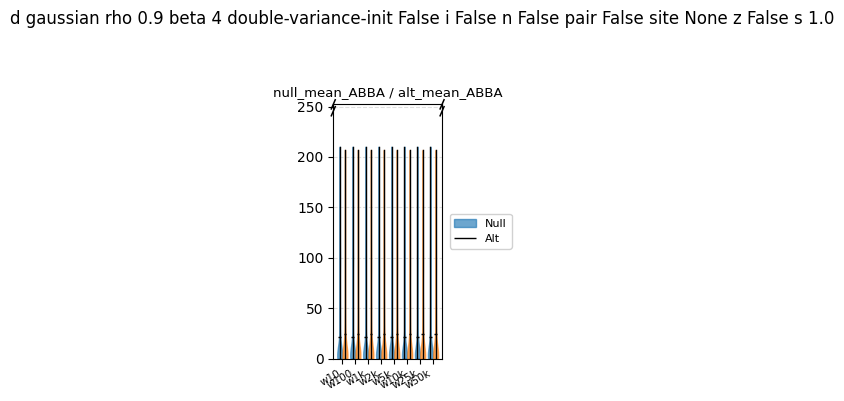

In [6]:
_TOPO_COLS = ["ABBA", "BABA", "AABB"]

# null_mean_*/alt_mean_* on runs.tsv are caster's ground-truth gt_stats.txt
# means (see benchmark.py's _build_record), independent of -d -- pin -d so
# gaussian/gmm reports of the same caster tree don't get pooled as duplicates.
#
# Null/Alt as a side-by-side hue only works via plot()'s tuple-metric
# sharing ("(null_mean_X, alt_mean_X)" -> one subplot per topology, hue =
# metric), which is single-level-agg only -- so -w stays a pooled axis here
# (averaged into each merged_category bar) rather than its own agg level;
# the earlier heatmap cell above already shows it barely varies by window
# anyway. The default multi-config legend (top-right, one line per
# merged_category with every metric's mean) is dropped since merged_category
# is already on the x-axis; each subplot's own Null/Alt legend is moved
# beside the axes instead of overlapping the bars.
figs = cra.plot(
    full_config,
    agg=["-w"],
    metrics=[(f"null_mean_{topo}", f"alt_mean_{topo}") for topo in _TOPO_COLS[:1]],
    plot_type="violin",
)
for fig in figs:
    for legend in list(fig.legends):
        legend.remove()
    for ax in fig.axes:
        if ax.get_legend() is not None:
            ax.legend(["Null", "Alt"], loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, framealpha=0.9)
    fig.tight_layout(rect=[0, 0, 0.88, 0.92])
plt.show()

# ILR

In [ ]:

_VARIANT_MARKERS = {"site", "ilr", "normalize"}


def caster_score_stats(root_dir):
    root_dir = Path(root_dir)
    score_files = [
        f for f in sorted(root_dir.rglob("scores.tsv"))
        if not any(p in _VARIANT_MARKERS for p in f.relative_to(root_dir).parts[:-1])
    ]
    if not score_files:
        raise FileNotFoundError(f"No scores.tsv found directly under {root_dir} (excluding site/ilr/normalize subtrees)")
    combined = pd.concat((pd.read_csv(f, sep="\t") for f in score_files), ignore_index=True)
    score_cols, rename_map = CasterPlotter.resolve_topology_columns(combined)
    stats = combined[score_cols].rename(columns=rename_map).agg(["mean", "std"]).T
    print(f"{len(score_files)} files, {len(combined)} rows")
    return stats


print(caster_score_stats('store/caster/w5k_s5k'))
print(caster_score_stats('store/caster/w5k_s5k/ilr'))

672 files, 806400 rows
              mean           std
ABBA   5414.790489  35080.717124
BABA   5443.013967  35419.536825
AABB  10035.643260  55819.187309
672 files, 806400 rows
            mean       std
c*ILR1 -0.068341  6.784287
c*ILR2 -3.727347  4.334861


### 2D ILR scatter for a run dir

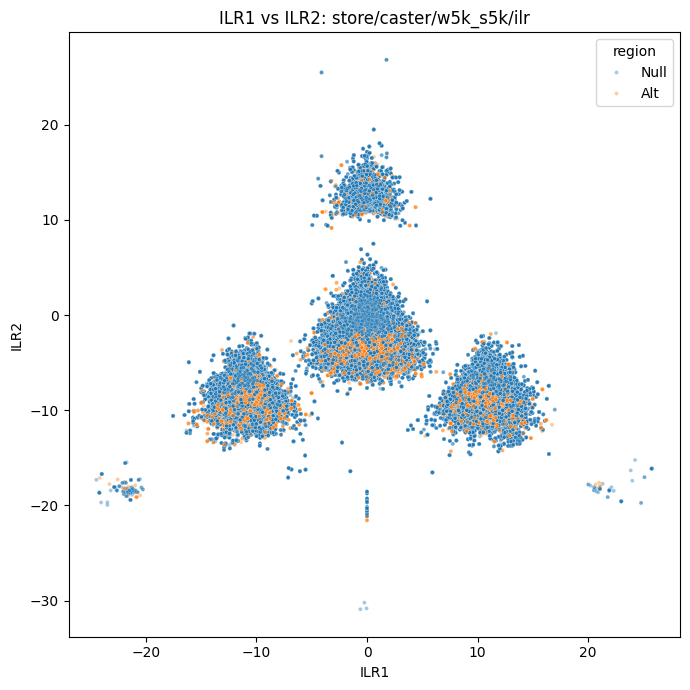

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from phlag.utils import parse_pattern_string


def _merged_category_scalar(category, subcategory):
    return category if category == "admixture" else f"{category} {subcategory}"


def plot_ilr_scatter(root_dir, color_by="merged_category", figsize=(7, 7), alpha=0.4, s=8):
    """
    Scatter-plots ILR1 (x) vs ILR2 (y) for every scores.tsv under root_dir, which
    must be an ILR-variant tree (e.g. 'store/caster/w5k_s5k/ilr' -- the -i/--ilr
    output, c*ILR1/c*ILR2 columns). Per-row Null/Alt ground truth is derived from
    each file's locus pattern directory (same split as write_ground_truth_stats),
    so color_by can be "merged_category", "changes" (the pattern), or "region"
    (Null/Alt).
    """
    root_dir = Path(root_dir)
    score_files = sorted(root_dir.rglob("scores.tsv"))
    if not score_files:
        raise FileNotFoundError(f"No scores.tsv found under {root_dir}")

    frames = []
    for f in score_files:
        rel_parts = f.relative_to(root_dir).parts
        if len(rel_parts) < 4:
            continue
        category, subcategory, _sim, pattern = rel_parts[:4]

        df = pd.read_csv(f, sep="\t")
        score_cols, _rename_map = CasterPlotter.resolve_topology_columns(df)
        ilr1_col = next((c for c in score_cols if "ILR1" in c.upper()), None)
        ilr2_col = next((c for c in score_cols if "ILR2" in c.upper()), None)
        if ilr1_col is None or ilr2_col is None or "pos" not in df.columns or df.empty:
            continue

        positions = df["pos"].to_numpy()
        _, anomaly_intervals, _ = parse_pattern_string(pattern, block_size_bp=500000, total_span=positions.max())
        is_alt = np.zeros(len(positions), dtype=bool)
        for start_bp, end_bp in anomaly_intervals:
            is_alt |= (positions >= start_bp) & (positions <= end_bp)

        frames.append(pd.DataFrame({
            "ILR1": df[ilr1_col],
            "ILR2": df[ilr2_col],
            "merged_category": _merged_category_scalar(category, subcategory),
            "changes": pattern,
            "region": np.where(is_alt, "Alt", "Null"),
        }))

    if not frames:
        raise ValueError(f"No ILR1/ILR2 columns found under {root_dir} -- point it at the -i/--ilr variant tree")

    combined = pd.concat(frames, ignore_index=True)

    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(data=combined, x="ILR1", y="ILR2", hue=color_by, alpha=alpha, s=s, ax=ax)
    ax.set_title(f"ILR1 vs ILR2: {root_dir}")
    plt.tight_layout()
    plt.show()
    return combined


_ = plot_ilr_scatter('store/caster/w5k_s5k/ilr', color_by="region")